Model performance
Accuracy : 0.9605769230769231
Precision: 0.9894736842105263
Recall   : 0.7014925373134329
F1 Score : 0.8209606986899564


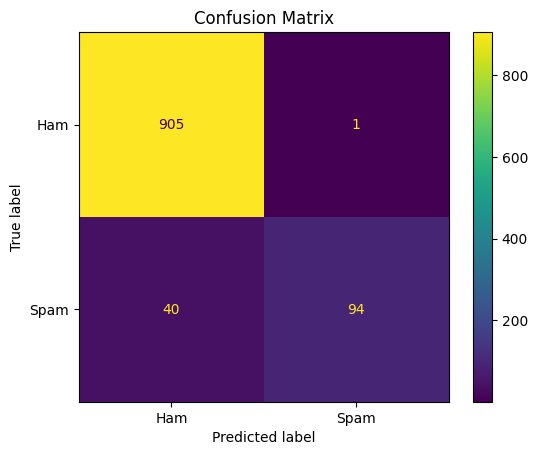


Model and vectorizer saved successfully!


In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pickle
import re# regular expression use for cleaning data
#import all required things
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

#load data
df = pd.read_csv("spam.csv",encoding='latin-1')
# Keep only required columns
df = df[['v1', 'v2']]
# Rename columns
df.columns = ['label', 'text']

# Convert labels into numeric form
# ham = 0 , spam = 1
df['label'] = df['label'].map({'ham': 0, 'spam': 1})

#add spam and non spam emails as well 
spam_emails = pd.DataFrame({
    "text": [
        "Dear customer your bank account has been suspended verify immediately",
        "Congratulations you have won a free iPhone click the link below",
        "Urgent action required update your payment information now",
        "You have been selected for a million dollar prize claim now",
        "Your PayPal account has been limited login immediately",
        "Win cash rewards by clicking this exclusive offer",
        "Security alert suspicious login detected verify your identity",
        "Your account password has expired reset now",
        "Get instant loan approval without documentation",
        "Limited time offer buy one get one free today",
        "Click here to receive your lottery winnings",
        "Your credit card has been blocked verify details now",
        "Exclusive investment opportunity earn thousands weekly",
        "You are selected for a free vacation package",
        "Open the attachment to receive your payment"
    ],

    "label": [1] * 15
})

ham_emails = pd.DataFrame({
    "text": [
        "Dear team the meeting is scheduled tomorrow at 10am",
        "Please review the attached project documentation",
        "Your interview has been confirmed for Monday",
        "Lunch meeting has been rescheduled to Friday",
        "The project deadline is extended till next week",
        "Your monthly invoice has been generated successfully",
        "Please send the updated report before evening",
        "Team discussion will be conducted in conference room",
        "Your order has been shipped successfully",
        "Thank you for attending today presentation",
        "Your application has been approved successfully",
        "Please complete your assignment before deadline",
        "Client feedback meeting is planned for tomorrow",
        "The training session starts at 2pm today",
        "Your account statement is attached for review"
    ],
    "label": [0] * 15
})

# Combine all datasets
email_df = pd.concat([spam_emails, ham_emails])
df = pd.concat([df, email_df], ignore_index=True)
# Remove duplicate rows
df.drop_duplicates(inplace=True)
# Remove null rows
df.dropna(inplace=True)

#clean useless data from text
def clean_text(text):
#re is used for removing useless data and for cleaning purposes
    # Convert to lowercase
    text = text.lower()
    # Remove URLs
    text = re.sub('rhttp+', '', text)
    # Remove numbers
    text = re.sub(r'\d+', '', text)
    # Remove punctuation
    text = re.sub(r'[^\w\s]', '', text)
    # Remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()
    return text

# Apply cleaning and remove 
df['text'] = df['text'].apply(clean_text)

#get feature and target 
X = df['text']
y = df['label']

#train test split 80% data for training and 20 for test
X_train, X_test, y_train, y_test = train_test_split(
    X,y,test_size=0.2,random_state=42
)
# converts text into numerical vectors
vectorizer = TfidfVectorizer(stop_words='english')
X_train= vectorizer.fit_transform(X_train)
X_test = vectorizer.transform(X_test)

#for classification use logisticregression model of it
model = LogisticRegression()
model.fit(X_train, y_train)

# predict on test data
y_pred = model.predict(X_test)

# calculate evaluation parameters 
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Model performance")
print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)
#display confusion matrix has TP,TN,FP,FN in its matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Ham", "Spam"]
)
disp.plot()
plt.title("Confusion Matrix")
plt.show()
pickle.dump(model, open("model.pkl", "wb"))
pickle.dump(vectorizer, open("vectorizer.pkl", "wb"))
print("\nModel and vectorizer saved successfully!")
#model has 96% percent accuracy and tells that it can predict 96 percent ham values
#model has 98% precision it means that 98% spam emails is detected by model it predicted correctly 
#model has 70 % recall it means that from actual spam messages model predict 70 percent spam correctly
#model has f1 score 82 percent it means that model is balanced